# add_damage_record.ipynb
Add a new damages record to the database.

In [1]:
%matplotlib widget
import ipympl
import matplotlib.pyplot as plt
import sqlite3
from icecream import ic 
import numpy as np
import shapely
from shapely import wkt
from pyefd import elliptic_fourier_descriptors, calculate_dc_coefficients, reconstruct_contour
import cv2
from shapely.geometry import Polygon
from shapely.wkt import dumps
import re
from contextlib import contextmanager

In [2]:
db_path = 'new.db'
image_id = 1
tree_id = 1
order = 15

In [3]:
@contextmanager
def open_db(db_path=db_path):
    conn = sqlite3.connect(db_path)
    try:
        # 1. Configure Row Factory (built-in dictionary-like rows)
        conn.row_factory = sqlite3.Row
        
        # 2. Load SpatiaLite Extension
        conn.enable_load_extension(True)
        conn.load_extension("mod_spatialite") 
        
        # Yield the fully configured connection
        yield conn
        
        conn.commit()
    except Exception:
        conn.rollback()
        raise
    finally:
        conn.close()

# Usage example:

db_path = 'new.db'
with open_db() as conn:
    cursor = conn.cursor()
    
    # You can now use SpatiaLite functions right away
    cursor.execute("SELECT image_id FROM images WHERE damage_flag = 0")
    
    # Because of sqlite3.Row, you can access columns by name!
    image_id_queue = [row['image_id'] for row in cursor.fetchall()]    
    
    # Connection is automatically committed and closed here.
    
ic(image_id_queue);       

ic| image_id_queue: [1, 2]


In [4]:
!jupyter notebook --version

7.5.6


In [5]:
# get WKTs for for trees in a selected image
with open_db() as conn:
    cursor = conn.cursor()
    cursor.execute(f'SELECT AsWKT(tree_poly) FROM trees WHERE image_id={image_id}')
    tree_wkts = cursor.fetchall()
    # ic(tree_wkts)
    ic(len(tree_wkts))

ic| len(tree_wkts): 2


In [6]:
# Get coordinates array for first tree
wkt_string = tree_wkts[0][0]  # Get the WKT string from the first row
ic(wkt_string)
# ic(wkt_string)
# 1. Load the WKT into a Shapely geometry object
polygon = wkt.loads(wkt_string)

# 2. Extract the exterior coordinates and convert to a NumPy array
coords_array = np.array(polygon.exterior.coords)
coords_array = np.abs(coords_array)  # Ensure all coordinates are positive

# ic(coords_array)
# ic(coords_array.shape);

ic| wkt_string: 'POLYGON((486 -677,486 -682,485 -683,485 -687,484 -688,484 -689,482 -691,481 -691,478 -694,478 -706,477 -707,477 -718,479 -720,479 -721,482 -724,482 -725,483 -725,486 -728,486 -729,489 -732,489 -733,490 -734,490 -735,491 -736,491 -740,490 -741,489 -741,488 -742,486 -742,485 -743,475 -743,474 -744,473 -744,474 -744,475 -745,476 -745,477 -746,478 -746,479 -747,483 -747,484 -748,486 -748,487 -749,490 -749,491 -750,493 -750,495 -752,495 -753,496 -754,496 -757,495 -758,495 -759,493 -761,493 -762,491 -764,490 -764,489 -765,489 -766,488 -767,487 -767,486 -768,486 -769,484 -771,484 -772,483 -773,483 -774,482 -775,482 -778,479 -781,478 -781,477 -782,476 -782,473 -785,473 -788,472 -789,472 -791,471 -792,471 -799,470 -800,470 -806,475 -811,476 -811,477 -812,478 -812,479 -813,480 -813,482 -815,483 -815,486 -818,486 -819,487 -820,487 -821,486 -822,485 -822,484 -821,477 -821,477 -822,479 -822,480 -823,482 -823,484 -825,485 -825,486 -826,487 -826,488 -827,490 -827,491 -828,493 -828,49

In [7]:
# get elliptic Fourier descriptors for first tree

original_contour = coords_array

num_harmonics=order

original_contour = np.array(original_contour, dtype=np.float64).reshape(-1, 2)
# ic(original_contour)

# 1. Extract descriptors (keep normalize=False to retain native spatial details)
coeffs = elliptic_fourier_descriptors(original_contour, order=num_harmonics, normalize=False)
# ic(coeffs)

# 2. Extract DC spatial tracking offsets
dc_coeffs = calculate_dc_coefficients(original_contour)
# ic(dc_coeffs)

# 3. Generate raw reconstruction (matching original row length for point parity)
reconstructed_contour = reconstruct_contour(
    coeffs, 
    locus=dc_coeffs, 
    num_points=len(original_contour)
)
# ic(reconstructed_contour)

ic| image_path: '/home/aubrey/Desktop/crbdd/resources/example_images/08hs-palms-03-zglw-superJumbo.webp'


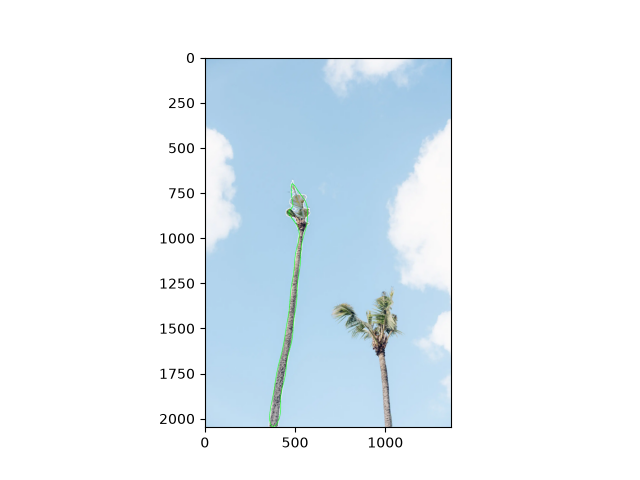

In [8]:
# display image with original contour and reconstructed contour for first tree

with open_db() as conn:
    cursor = conn.cursor()
    cursor.execute(f'SELECT image_path FROM images WHERE image_id = {image_id}')
    image_path = cursor.fetchone()['image_path']
    ic(image_path)
    
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# ic(img)

cv2.polylines(img, pts=[original_contour.astype(np.int32)], isClosed=True, color=(255, 255, 255), thickness=2)
# ic(img)

cv2.polylines(img, pts=[reconstructed_contour.astype(np.int32)], isClosed=True, color=(0,255,0), thickness=2)

# 4. Initialize the figure and axes for the widget window
fig, ax = plt.subplots()

# 5. Render the image inside the interactive widget frame
ax.imshow(img)
plt.show()

In [9]:
# calculate mask containing pixels which are in the reconstruction mask but not in the original mask

original_mask = np.zeros_like(img, dtype=np.uint8)
cv2.fillPoly(original_mask, pts=[original_contour.astype(dtype=np.int32)], color=255)

reconstructed_mask = np.zeros_like(img, dtype=np.uint8)
cv2.fillPoly(reconstructed_mask, pts=[reconstructed_contour.astype(dtype=np.int32)], color=255)

# Pixels missing in original, present in reconstruction
diff_mask = cv2.bitwise_and(reconstructed_mask, cv2.bitwise_not(original_mask))

# remove small blobs using connected components method
#######################################################

# Load your binary image (must be single-channel, uint8)
binary_img = cv2.cvtColor(diff_mask, cv2.COLOR_BGR2GRAY)
ic(binary_img.shape)

# 1. Find all connected components and their statistics
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_img, connectivity=8)

# 2. Define your minimum area threshold (in pixels)
min_area = 200 

# 3. Create an empty mask to store large objects
filtered_img = np.zeros_like(binary_img)

# 4. Loop through components (skip index 0 as it represents the background)
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    
    if area >= min_area:
        # Keep components that meet the size constraint
        filtered_img[labels == i] = 255
        

# Find connected components
num_labels, labels_im = cv2.connectedComponents(filtered_img)

# The background is counted as a label, so subtract 1 to get the blob count
blob_count = num_labels - 1

ic(blob_count)
###########################################################################3        

# ic(diff_mask)
# ic(np.max(diff_mask))

# gray_mask = cv2.cvtColor(diff_mask, cv2.COLOR_BGR2GRAY)
damage_polygons, _ = cv2.findContours(
    image=filtered_img, 
    mode=cv2.RETR_EXTERNAL, 
    method=cv2.CHAIN_APPROX_NONE)
# ic(len(damage_polygons));
# ic(damage_polygons[0])


# fig, ax = plt.subplots()
# ax.imshow(filtered_img)
# plt.show()

ic| binary_img.shape: (2048, 1366)
ic| blob_count: 9


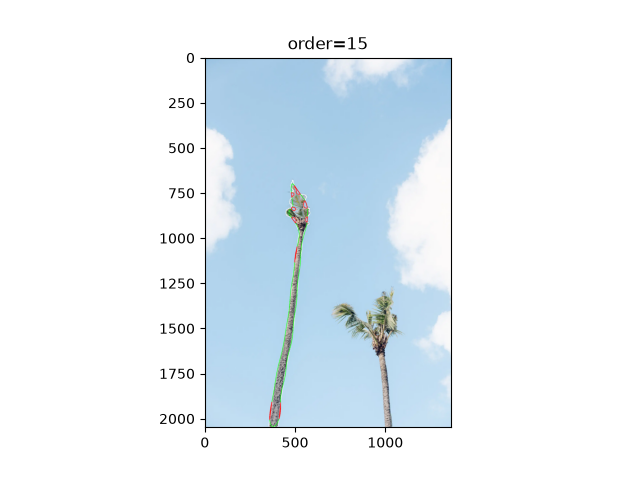

In [10]:
#  Add damage polygons to image

for damage_polygon in damage_polygons:
    cv2.polylines(img, 
                  pts=[damage_polygon.astype(np.int32)], 
                  isClosed=True, 
                  color=(255,0,0), 
                  thickness=2
    )   
fig, ax = plt.subplots()
ax.imshow(img)
ax.set_title(f'{order=}')
plt.show()

In [ ]:
# MAIN

# open database

# add damage_flag field to images table if it does not exist THIS BLOCK IS TEMPORARY
with open_db() as conn: 
    cursor = conn.cursor()
    try:
        # Attempt to add the column
        cursor.execute("ALTER TABLE images ADD COLUMN damage_flag INTEGER NOT NULL DEFAULT 0;")
        conn.commit()
        ic("damage_flag column added successfully!")
    except sqlite3.OperationalError as e:
        # If the error is because the column already exists, ignore it safely
        if "duplicate column name" in str(e):
            ic("damage_flag column already exists. Skipping.")
        else:
            # Re-raise if it's a completely different database error
            raise e
        
# get image_id_queue containing a list of image_ids for damage shape processing
with open_db() as conn: 
    cursor = conn.cursor()       
    cursor.execute("SELECT image_id FROM images WHERE damage_flag = 0")
    image_id_queue =[row['image_id'] for row in cursor.fetchall()]      

# get tree_id_queue containing a list of image_ids for damage shape processing
for image_id in image_id_queue:   
    with open_db() as conn:
        cursor = conn.cursor()
        cursor.execute(f'SELECT tree_id FROM trees WHERE image_id={image_id}')
        tree_id_queue = [row['tree_id'] for row in cursor.fetchall()]
        ic(image_id, tree_id_queue)  

# process tree_queue        
for tree_id in tree_id_queue:
    
    # get WKT for tree polygon
    with open_db() as conn: 
        cursor = conn.cursor()       
        cursor.execute(f'SELECT AsText(tree_poly) AS tree_wkt FROM trees WHERE tree_id={tree_id}')
        tree_wkt = cursor.fetchone()['tree_wkt']
        # ic(tree_id, tree_wkt)
        
    # get coords
        
    # 1. Load the WKT into a Shapely geometry object
    polygon = wkt.loads(tree_wkt)

    # 2. Extract the exterior coordinates and convert to a NumPy array
    coords_array = np.array(polygon.exterior.coords)
    coords_array = np.abs(coords_array)  # Ensure all coordinates are positive
    
    # get elliptic Fourier descriptors

    original_contour = coords_array
    original_contour = np.array(original_contour, dtype=np.float64).reshape(-1, 2)
    # ic(original_contour)

    # 1. Extract descriptors (keep normalize=False to retain native spatial details)
    coeffs = elliptic_fourier_descriptors(original_contour, order=order, normalize=False)
    # ic(coeffs)

    # 2. Extract DC spatial tracking offsets
    dc_coeffs = calculate_dc_coefficients(original_contour)
    # ic(dc_coeffs)

    # 3. Generate raw reconstruction (matching original row length for point parity)
    reconstructed_contour = reconstruct_contour(
        coeffs, 
        locus=dc_coeffs, 
        num_points=len(original_contour)
    )
    # ic(reconstructed_contour)

        
    

    
             

ic| 'damage_flag column already exists. Skipping.'
ic| image_id: 1, tree_id_queue: [1, 2]
ic| image_id: 2
    tree_id_queue: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
ic| tree_id: 3
    tree_wkt: 'POLYGON((1153 -233, 1152 -234, 1151 -234, 1150 -235, 1149 -235, 1149 -241, 1151 -243, 1151 -245, 1152 -246, 1152 -247, 1153 -248, 1153 -249, 1154 -250, 1154 -252, 1155 -253, 1155 -256, 1156 -257, 1156 -262, 1155 -263, 1155 -275, 1154 -276, 1154 -287, 1153 -288, 1153 -289, 1152 -290, 1152 -291, 1147 -296, 1143 -296, 1140 -293, 1140 -291, 1139 -290, 1139 -288, 1138 -287, 1138 -286, 1137 -285, 1137 -284, 1136 -283, 1136 -281, 1135 -280, 1135 -273, 1134 -272, 1134 -264, 1133 -263, 1133 -262, 1132 -261, 1131 -261, 1127 -257, 1127 -256, 1125 -254, 1125 -252, 1122 -255, 1122 -256, 1121 -257, 1121 -258, 1120 -259, 1120 -260, 1119 -261, 1119 -263, 1117 -265, 1116 -265, 1107 -274, 1105 -274, 1104 -275, 1103 -275, 1102 -276, 1099 -276, 1098 -277, 1

In [12]:
ic('FINISHED')

ic| 'FINISHED'


'FINISHED'